# 🏠  Projeto Airbnb Rio - Ferramenta de Previsão de Preço de Imóvel para pessoas comuns 

## 📌 Introdução

O mercado de hospedagem por meio de plataformas como o Airbnb tem crescido significativamente, tornando a definição de preços uma tarefa estratégica para anfitriões. A precificação adequada de um imóvel depende de diversos fatores, como localização, capacidade, tipo de acomodação e características estruturais.

Diante desse contexto, este projeto tem como objetivo analisar os principais fatores que influenciam o preço de imóveis disponíveis no Airbnb no Rio de Janeiro, utilizando técnicas de análise de dados e machine learning.

Ao longo do projeto, serão realizadas etapas de exploração e tratamento dos dados, seguidas pela construção de um modelo preditivo capaz de estimar o valor das diárias com base nas características dos imóveis.

O intuito é demonstrar como a utilização de dados pode auxiliar na tomada de decisão e na compreensão do mercado imobiliário de curto prazo.

## 🎯 Objetivo
Desenvolver um modelo preditivo que estime o preço de um imóvel no Airbnb com base em variáveis como:

- Localização
- Tipo de propriedade
- Número de quartos e camas
- Comodidades
- Regras do anúncio

O objetivo final é auxiliar anfitriões na tomada de decisão sobre precificação.

### O que temos disponível, inspirações e créditos

As bases de dados foram retiradas do site kaggle: https://www.kaggle.com/allanbruno/airbnb-rio-de-janeiro

Elas estão disponíveis para download abaixo da aula (se você puxar os dados direto do Kaggle pode ser que encontre resultados diferentes dos meus, afinal as bases de dados podem ter sido atualizadas).

Caso queira uma outra solução, podemos olhar como referência a solução do usuário Allan Bruno do kaggle no Notebook: https://www.kaggle.com/allanbruno/helping-regular-people-price-listings-on-airbnb

Você vai perceber semelhanças entre a solução que vamos desenvolver aqui e a dele, mas também algumas diferenças significativas no processo de construção do projeto.

- As bases de dados são os preços dos imóveis obtidos e suas respectivas características em cada mês.
- Os preços são dados em reais (R$)
- Temos bases de abril de 2018 a maio de 2020, com exceção de junho de 2018 que não possui base de dados

### Expectativas Iniciais

- Acredito que a sazonalidade pode ser um fator importante, visto que meses como dezembro costumam ser bem caros no RJ
- A localização do imóvel deve fazer muita diferença no preço, já que no Rio de Janeiro a localização pode mudar completamente as características do lugar (segurança, beleza natural, pontos turísticos)
- Adicionais/Comodidades podem ter um impacto significativo, visto que temos muitos prédios e casas antigos no Rio de Janeiro

Vamos descobrir o quanto esses fatores impactam e se temos outros fatores não tão intuitivos que são extremamente importantes.

### Importar Bibliotecas e Bases de Dados

In [57]:
import pandas as pd
import pathlib
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.model_selection import train_test_split

### Consolidar Base de Dados

In [58]:
caminho_base = pathlib.Path('dataset')

base_airbnb = pd.DataFrame()
lista_df = []
meses = {'jan': 1, 'fev': 2, 'mar': 3, 'abr': 4, 'mai': 5, 'jun': 6, 'jul': 7, 'ago': 8, 'set': 9, 'out': 10, 'nov': 11, 'dez': 12}


for arquivo in caminho_base.iterdir():
    nome_mes = arquivo.name[:3]
    mes = meses[nome_mes]
    
    ano = arquivo.name[-8:]
    ano = int(ano.replace('.csv', ''))
    
    df = pd.read_csv(fr'dataset\{arquivo.name}')
    df['ano'] = ano
    df['mes'] = mes
    lista_df.append(df)

base_airbnb = pd.concat(lista_df, ignore_index=True)
display(base_airbnb)

C:\Users\guilh\AppData\Local\Temp\ipykernel_3356\1265005163.py:15: DtypeWarning: Columns (0: monthly_price, 1: license) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(fr'dataset\{arquivo.name}')
C:\Users\guilh\AppData\Local\Temp\ipykernel_3356\1265005163.py:15: DtypeWarning: Columns (0: weekly_price, 1: monthly_price, 2: license) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(fr'dataset\{arquivo.name}')
C:\Users\guilh\AppData\Local\Temp\ipykernel_3356\1265005163.py:15: DtypeWarning: Columns (0: weekly_price, 1: monthly_price, 2: license) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(fr'dataset\{arquivo.name}')
C:\Users\guilh\AppData\Local\Temp\ipykernel_3356\1265005163.py:15: DtypeWarning: Columns (0: license) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(fr'dataset\{arquivo.name}')
C:\Users\guilh\AppDa

,id,listing_url,scrape_id,last_scraped,name,summary,space,description,experiences_offered,neighborhood_overview,...,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,number_of_reviews_ltm,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms
0,14063,https://www.airbnb.com/rooms/14063,20180414160018,2018-04-14,Living in a Postcard,"Besides the most iconic's view, our apartment ...",NaN,"Besides the most iconic's view, our apartment ...",none,Best and favorite neighborhood of Rio. Perfect...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,17878,https://www.airbnb.com/rooms/17878,20180414160018,2018-04-14,Very Nice 2Br - Copacabana - WiFi,Please note that special rates apply for New Y...,- large balcony which looks out on pedestrian ...,Please note that special rates apply for New Y...,none,This is the best spot in Rio. Everything happe...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,24480,https://www.airbnb.com/rooms/24480,20180414160018,2018-04-14,Nice and cozy near Ipanema Beach,My studio is located in the best of Ipanema. ...,The studio is located at Vinicius de Moraes St...,My studio is located in the best of Ipanema. ...,none,"The beach, the lagoon, Ipanema is a great loca...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,25026,https://www.airbnb.com/rooms/25026,20180414160018,2018-04-14,Beautiful Modern Decorated Studio in Copa,"Our apartment is a little gem, everyone loves ...",This newly renovated studio (last renovations ...,"Our apartment is a little gem, everyone loves ...",none,Copacabana is a lively neighborhood and the ap...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,31560,https://www.airbnb.com/rooms/31560,20180414160018,2018-04-14,NICE & COZY 1BDR - IPANEMA BEACH,This nice and clean 1 bedroom apartment is loc...,This nice and clean 1 bedroom apartment is loc...,This nice and clean 1 bedroom apartment is loc...,none,Die Nachbarschaft von Ipanema ist super lebend...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
902205,38844730,https://www.airbnb.com/rooms/38844730,20190923212307,2019-09-24,TRANSAMERICA BARRA DA TIJUCA R IV,"Em estilo contemporâneo, o Transamerica Prime ...",NaN,"Em estilo contemporâneo, o Transamerica Prime ...",none,NaN,...,1.0,1.0,1125.0,1125.0,1.0,1125.0,0.0,15.0,0.0,0.0
902206,38846408,https://www.airbnb.com/rooms/38846408,20190923212307,2019-09-24,Alugo para o Rock in Rio,"Confortável apartamento, 2 quartos , sendo 1 s...",O apartamento estará com mobília completa disp...,"Confortável apartamento, 2 quartos , sendo 1 s...",none,"Muito próximo ao Parque Olímpico, local do eve...",...,2.0,2.0,1125.0,1125.0,2.0,1125.0,0.0,1.0,0.0,0.0
902207,38846703,https://www.airbnb.com/rooms/38846703,20190923212307,2019-09-24,Apt COMPLETO em COPACABANA c/TOTAL SEGURANÇA,Apartamento quarto e sala COMPLETO para curtas...,Espaço ideal para até 5 pessoas. Cama de casal...,Apartamento quarto e sala COMPLETO para curtas...,none,NaN,...,3.0,3.0,1125.0,1125.0,3.0,1125.0,0.0,23.0,6.0,0.0
902208,38847050,https://www.airbnb.com/rooms/38847050,20190923212307,2019-09-24,Cobertura Cinematografica,Cobertura alto nivel,NaN,Cobertura alto nivel,none,NaN,...,1.0,1.0,1125.0,1125.0,1.0,1125.0,0.0,1.0,0.0,0.0


## 🧹 Limpeza e Tratamento dos Dados

Nesta etapa foram realizadas:

- Remoção de colunas irrelevantes
- Tratamento de valores ausentes
- Conversão de variáveis categóricas
- Padronização dos dados

Além disso, aplicamos técnicas de encoding para transformar variáveis categóricas em formato numérico (One-Hot Encoding).

In [ ]:
base_airbnb.head(100).to_csv('dados_tratado/primeiros_registros.csv', sep=';')

### depois da analise qualitativa das colunas, levando em conta dos criterios explicados acima, ficamos com as seguintes colunas 

In [60]:
colunas = ['host_response_time', 'host_response_rate', 'host_is_superhost', 'host_total_listings_count', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'bed_type', 'amenities', 'price', 'security_deposit', 'cleaning_fee', 'guests_included', 'extra_people', 'minimum_nights', 'maximum_nights', 'number_of_reviews', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'instant_bookable', 'is_business_travel_ready', 'cancellation_policy', 'ano', 'mes'
           ]

base_airbnb = base_airbnb.loc[:, colunas]
display(base_airbnb)

,host_response_time,host_response_rate,host_is_superhost,host_total_listings_count,latitude,longitude,property_type,room_type,accommodates,bathrooms,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,is_business_travel_ready,cancellation_policy,ano,mes
0,NaN,NaN,f,1.0,-22.946854,-43.182737,Apartment,Entire home/apt,4,1.0,...,9.0,9.0,9.0,9.0,9.0,f,f,strict_14_with_grace_period,2018,4
1,within an hour,100%,t,2.0,-22.965919,-43.178962,Condominium,Entire home/apt,5,1.0,...,9.0,10.0,10.0,9.0,9.0,t,f,strict,2018,4
2,within an hour,100%,f,1.0,-22.985698,-43.201935,Apartment,Entire home/apt,2,1.0,...,10.0,10.0,10.0,10.0,9.0,f,f,strict,2018,4
3,within an hour,100%,f,3.0,-22.977117,-43.190454,Apartment,Entire home/apt,3,1.0,...,10.0,10.0,10.0,10.0,9.0,f,f,strict,2018,4
4,within an hour,100%,t,1.0,-22.983024,-43.214270,Apartment,Entire home/apt,3,1.0,...,10.0,10.0,10.0,10.0,9.0,t,f,strict,2018,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
902205,within an hour,93%,f,0.0,-23.003180,-43.342840,Apartment,Entire home/apt,4,1.0,...,NaN,NaN,NaN,NaN,NaN,f,f,flexible,2019,9
902206,NaN,NaN,f,0.0,-22.966640,-43.393450,Apartment,Entire home/apt,4,2.0,...,NaN,NaN,NaN,NaN,NaN,f,f,flexible,2019,9
902207,within a few hours,74%,f,32.0,-22.962080,-43.175520,Apartment,Entire home/apt,5,1.0,...,NaN,NaN,NaN,NaN,NaN,f,f,strict_14_with_grace_period,2019,9
902208,NaN,NaN,f,0.0,-23.003400,-43.341820,Apartment,Entire home/apt,4,1.0,...,NaN,NaN,NaN,NaN,NaN,f,f,strict_14_with_grace_period,2019,9


### Tratar Valores Faltando

- visualizando os dados, percebemos que existe uma grande disparidade em dados faltantes. As colunas com mais de 300.000 valores NaN foram excluidas da analise.
- para as outras colunas, como temos muitos dados (mais de 900.000 linhas) vamos ecxluir as linhas que contem dados NaN

In [61]:
for coluna in base_airbnb:
    if base_airbnb[coluna].isnull().sum() > 300000:
        base_airbnb = base_airbnb.drop(coluna, axis=1)
        
base_airbnb = base_airbnb.dropna()

print(base_airbnb.isnull().sum())


host_is_superhost            0
host_total_listings_count    0
latitude                     0
longitude                    0
property_type                0
room_type                    0
accommodates                 0
bathrooms                    0
bedrooms                     0
beds                         0
bed_type                     0
amenities                    0
price                        0
guests_included              0
extra_people                 0
minimum_nights               0
maximum_nights               0
number_of_reviews            0
instant_bookable             0
is_business_travel_ready     0
cancellation_policy          0
ano                          0
mes                          0
dtype: int64


### Verificar Tipos de Dados em cada coluna

In [62]:
print(base_airbnb.dtypes)
print('-'*60)
print(base_airbnb.iloc[0])

host_is_superhost                str
host_total_listings_count    float64
latitude                     float64
longitude                    float64
property_type                    str
room_type                        str
accommodates                   int64
bathrooms                    float64
bedrooms                     float64
beds                         float64
bed_type                         str
amenities                        str
price                            str
guests_included                int64
extra_people                     str
minimum_nights                 int64
maximum_nights                 int64
number_of_reviews              int64
instant_bookable                 str
is_business_travel_ready         str
cancellation_policy              str
ano                            int64
mes                            int64
dtype: object
------------------------------------------------------------
host_is_superhost                                                         

- como o preço e o extra people estao sendo reconhecidos como objeto (ao invés de float) temos que mudar o tipo de valiavel da coluna 

In [63]:
# price
base_airbnb['price'] = base_airbnb['price'].str.replace('$', '')
base_airbnb['price'] = base_airbnb['price'].str.replace(',', '')
base_airbnb['price'] = base_airbnb['price'].astype(np.float32, copy=False)
# extra_people
base_airbnb['extra_people'] = base_airbnb['extra_people'].str.replace('$', '')
base_airbnb['extra_people'] = base_airbnb['extra_people'].str.replace(',', '')
base_airbnb['extra_people'] = base_airbnb['extra_people'].astype(np.float32, copy=False)
#verificando os tipos
print(base_airbnb.dtypes)

C:\Users\guilh\AppData\Local\Temp\ipykernel_3356\816585832.py:4: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  base_airbnb['price'] = base_airbnb['price'].astype(np.float32, copy=False)


host_is_superhost                str
host_total_listings_count    float64
latitude                     float64
longitude                    float64
property_type                    str
room_type                        str
accommodates                   int64
bathrooms                    float64
bedrooms                     float64
beds                         float64
bed_type                         str
amenities                        str
price                        float32
guests_included                int64
extra_people                 float32
minimum_nights                 int64
maximum_nights                 int64
number_of_reviews              int64
instant_bookable                 str
is_business_travel_ready         str
cancellation_policy              str
ano                            int64
mes                            int64
dtype: object


C:\Users\guilh\AppData\Local\Temp\ipykernel_3356\816585832.py:8: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  base_airbnb['extra_people'] = base_airbnb['extra_people'].astype(np.float32, copy=False)


## 🔍 Análise Exploratória de Dados

Foram analisadas as relações entre variáveis e o preço, buscando identificar padrões importantes:

- Impacto da localização no preço
- Relação entre número de quartos e valor da diária
- Diferença entre tipos de propriedade
- Influência de comodidades

Essas análises ajudam a entender quais fatores mais influenciam o preço.

- Observamos que imóveis com maior número de quartos tendem a ter preços mais elevados.

<Axes: >

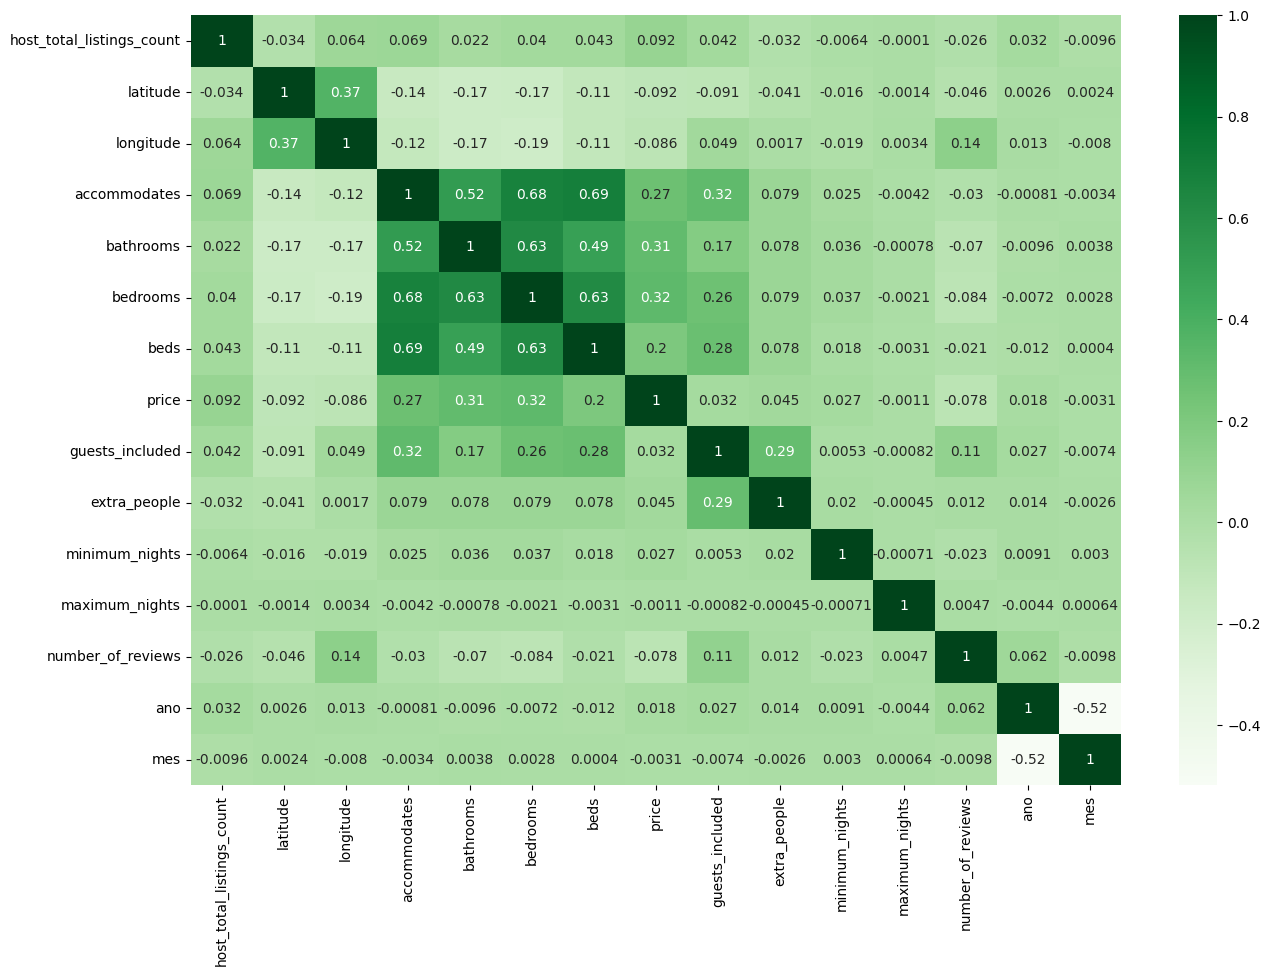

In [64]:
def limites(coluna):
    q1 = coluna.quantile(0.25)
    q3 = coluna.quantile(0.75)
    amplitude = q3 - q1
    return q1 - 1.5 * amplitude, q3 + 1.5 * amplitude


def diagrama_caixa(coluna):
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(15,5)
    sns.boxplot(x=coluna, ax=ax1)
    ax2.set_xlim(limites(coluna))
    sns.boxplot(x=coluna, ax=ax2)   


def histograma(coluna):
    plt.figure(figsize=(15,5))
    sns.histplot(coluna, kde=True)
    plt.show()
    

def grafico_barra(coluna):
    plt.figure(figsize=(15,5))
    ax = sns.barplot(x=coluna.value_counts().index, y=coluna.value_counts(), palette='viridis')
    ax.set_xlim(limites(coluna))
    
    
    
def excluir_outliners(df, nome_coluna):
    qtde_linas = df.shape[0]
    limite_inf, limite_sup = limites(df[nome_coluna])
    df = df.loc[(df[nome_coluna] >= limite_inf) & (df[nome_coluna] <= limite_sup), :]
    linhas_removidas = qtde_linas - df.shape[0]
    return df, linhas_removidas
    
    
plt.figure(figsize=(15, 10))
sns.heatmap(base_airbnb.corr(numeric_only=True), annot=True, cmap='Greens')

### 📊 Distribuição de preços (price)

A variável *price* representa o valor da diária dos imóveis.

**Principais insights:**
- A distribuição é assimétrica, com presença de valores muito altos
- Existem outliers que podem distorcer a análise
- A maioria dos imóveis está concentrada em faixas de preço mais baixas

**Conclusão:**
O tratamento de outliers é essencial para melhorar a qualidade das análises e o desempenho do modelo preditivo.

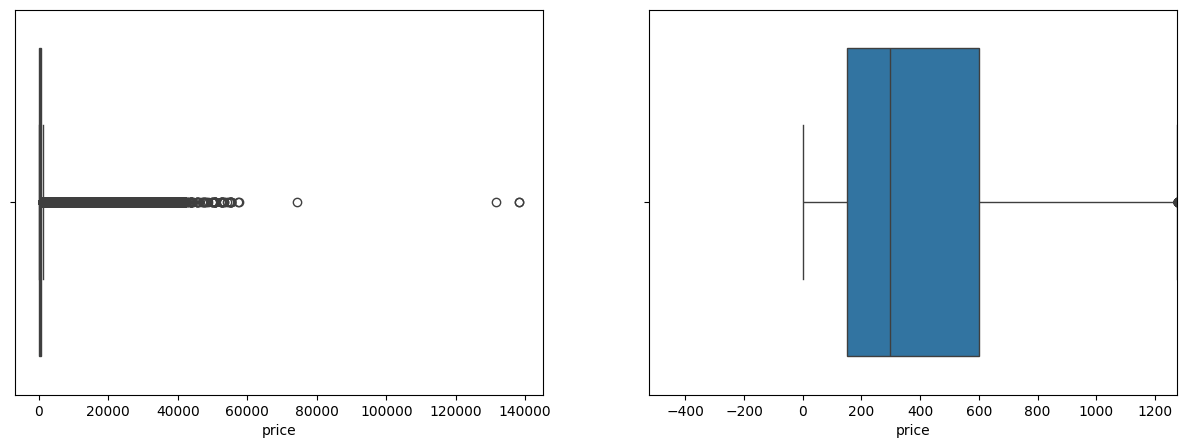

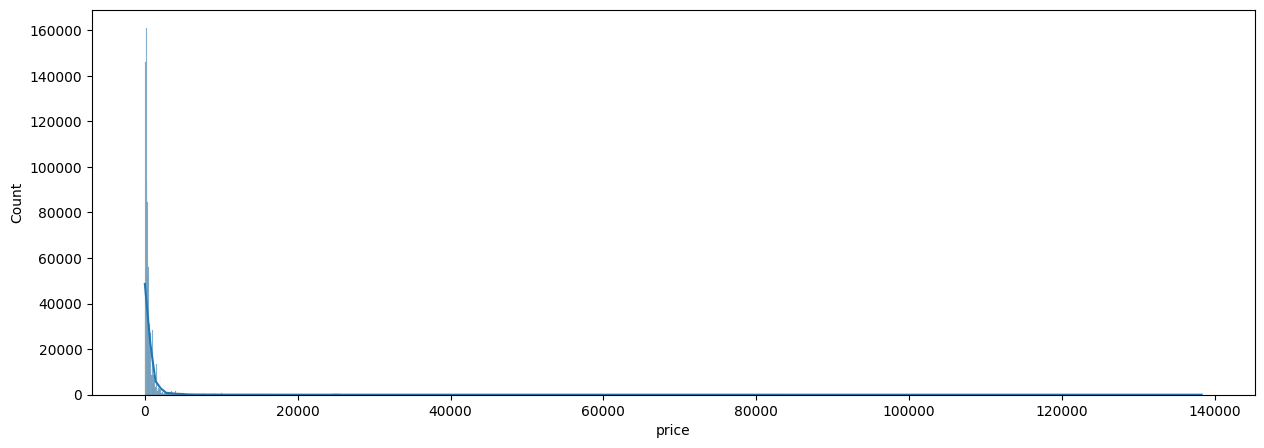

In [65]:
diagrama_caixa(base_airbnb['price'])
histograma(base_airbnb['price'])

87282


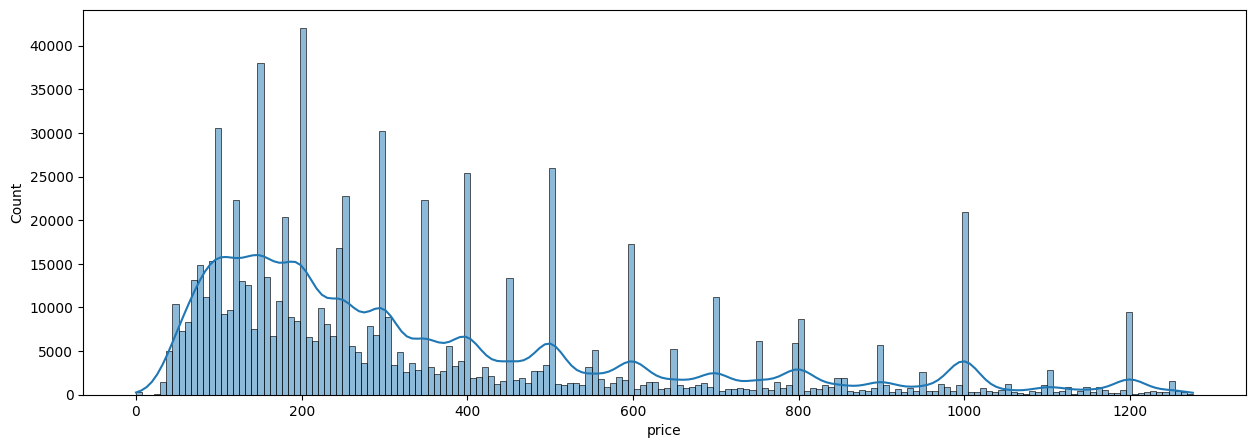

In [66]:
base_airbnb, linhas_removidas = excluir_outliners(base_airbnb, 'price')
print(linhas_removidas)
histograma(base_airbnb['price'])

### 📊 Taxa por pessoa extra (extra_people)

A variável *extra_people* representa o custo adicional cobrado por hóspedes extras.

**Principais insights:**
- Grande parte dos imóveis não cobra taxa adicional
- Valores estão concentrados próximos de zero
- Pode indicar estratégias diferentes de precificação

**Conclusão:**
A variável apresenta baixa variabilidade, podendo ter impacto limitado no modelo.

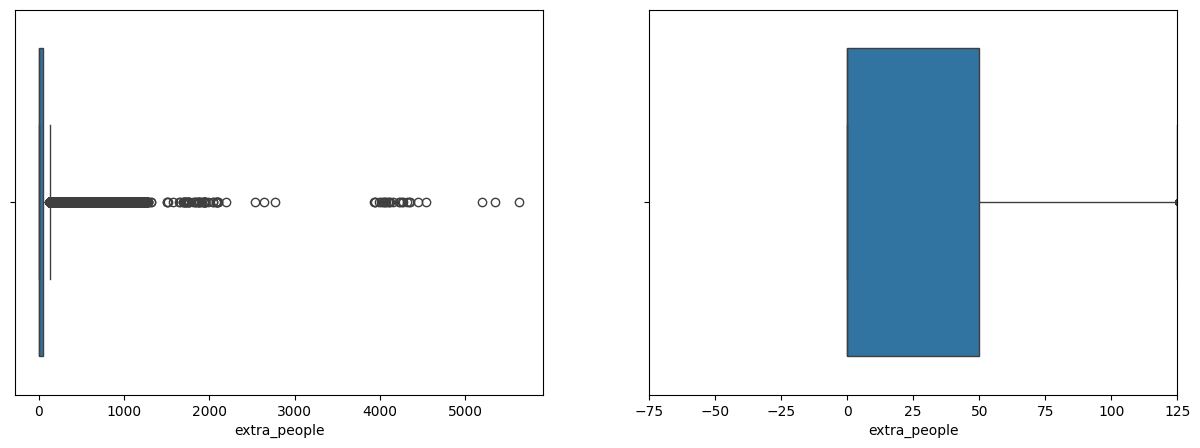

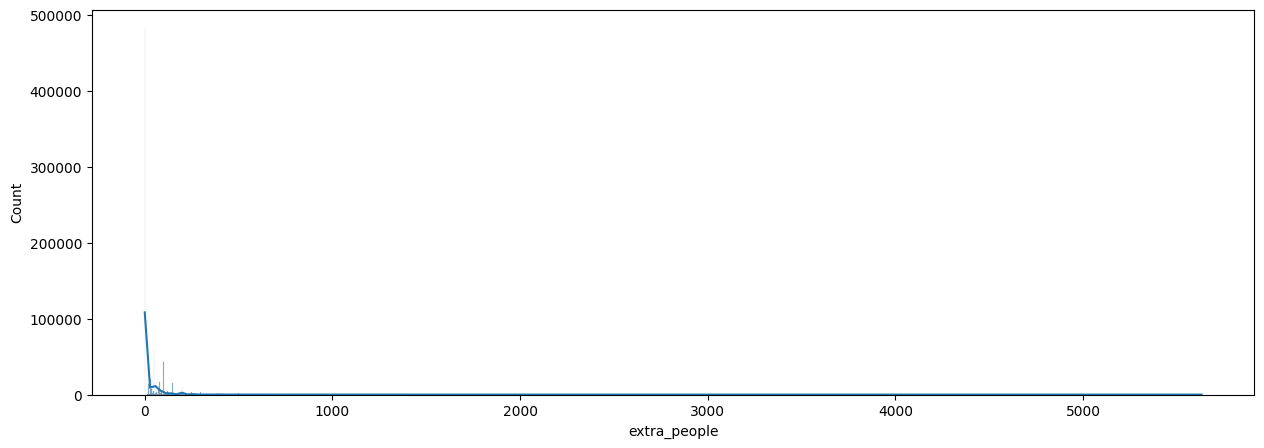

In [67]:
diagrama_caixa(base_airbnb['extra_people'])
histograma(base_airbnb['extra_people'])
base_airbnb, linhas_removidas = excluir_outliners(base_airbnb,'extra_people')   

### 📊 Total de anúncios do anfitrião (host_total_listings_count)

Essa variável representa quantos imóveis um anfitrião possui.

**Principais insights:**
- A maioria dos anfitriões possui poucos imóveis
- Alguns possuem múltiplos anúncios

**Conclusão:**
como queremos contruir um sistema para pessoas que possiu pouco imoveis vamos excluir os outliers.

C:\Users\guilh\AppData\Local\Temp\ipykernel_3356\1083544406.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=coluna.value_counts().index, y=coluna.value_counts(), palette='viridis')


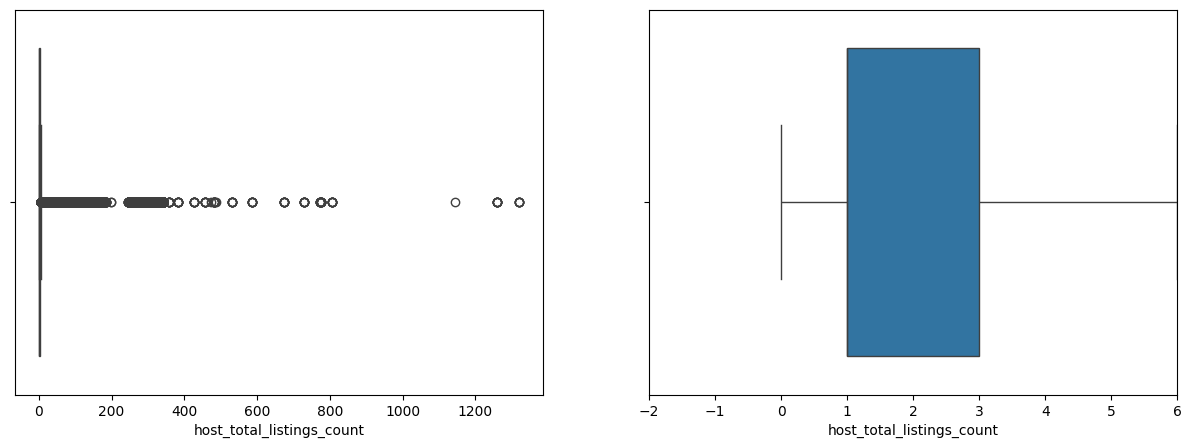

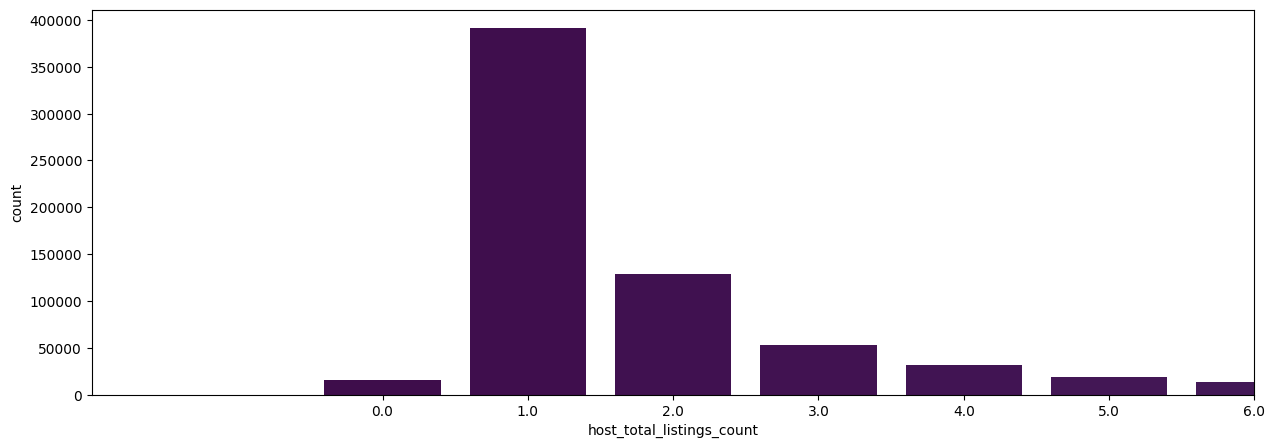

In [68]:
diagrama_caixa(base_airbnb['host_total_listings_count'])
grafico_barra(base_airbnb['host_total_listings_count'])
base_airbnb, linhas_removidas = excluir_outliners(base_airbnb, 'host_total_listings_count')

### 📊 Capacidade de hóspedes (accommodates)

A variável *accommodates* representa o número máximo de pessoas que o imóvel pode acomodar.

**Principais insights:**
- A maior parte dos imóveis acomoda entre 2 e 4 pessoas
- Imóveis com alta capacidade são menos frequentes
- Existe uma tendência de aumento de preço conforme a capacidade aumenta

**Conclusão:**
Essa variável é altamente relevante para o modelo, pois está diretamente relacionada ao valor do imóvel.

C:\Users\guilh\AppData\Local\Temp\ipykernel_3356\1083544406.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=coluna.value_counts().index, y=coluna.value_counts(), palette='viridis')


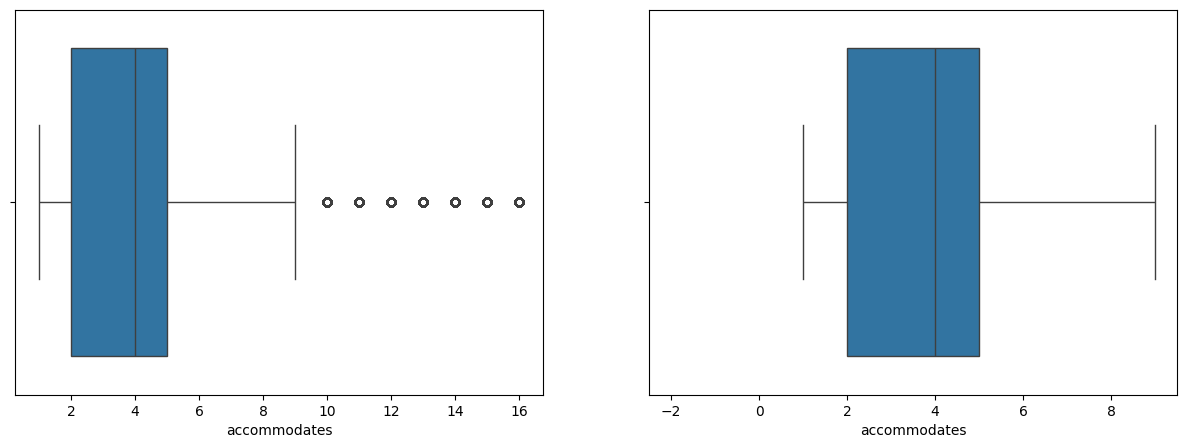

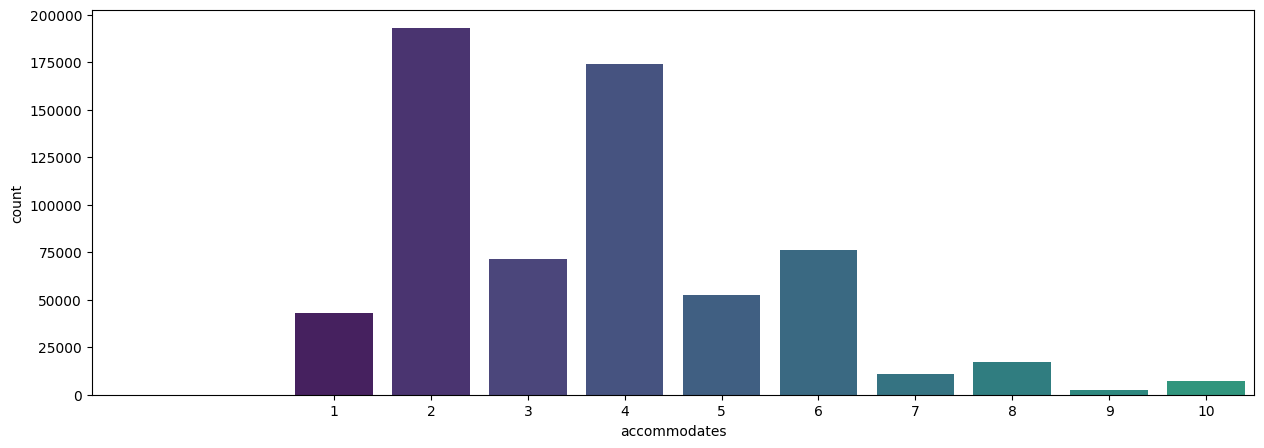

In [69]:
diagrama_caixa(base_airbnb['accommodates'])
grafico_barra(base_airbnb['accommodates'])
base_airbnb, linhas_removidas = excluir_outliners(base_airbnb,'accommodates')

### 📊 Número de banheiros (bathrooms)

A variável *bathrooms* indica a quantidade de banheiros disponíveis no imóvel.

**Principais insights:**
- A maioria dos imóveis possui 1 banheiro
- Poucos imóveis possuem mais de 2 banheiros
- Distribuição concentrada em valores baixos

**Conclusão:**
Apesar de relevante, essa variável possui baixa variação e tende a ter impacto moderado no preço.

C:\Users\guilh\AppData\Local\Temp\ipykernel_3356\1083544406.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=coluna.value_counts().index, y=coluna.value_counts(), palette='viridis')


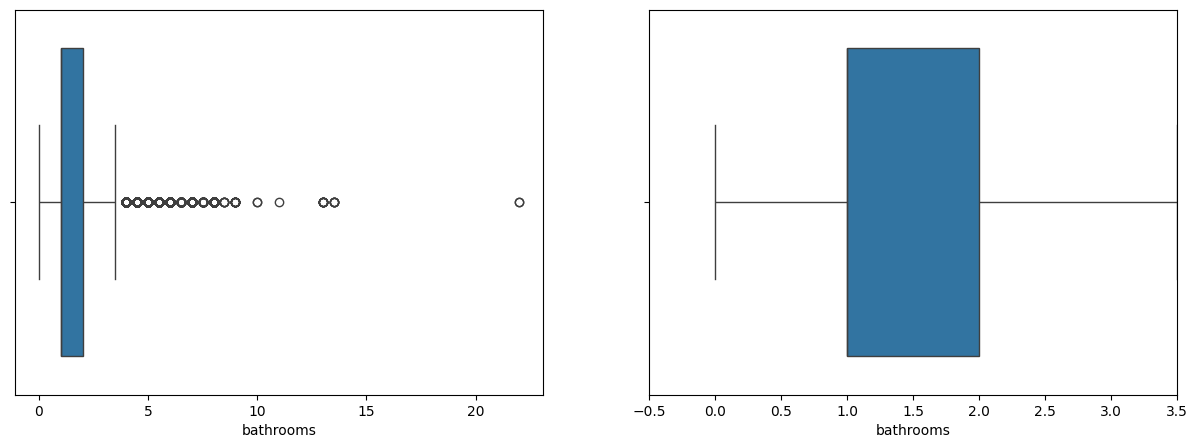

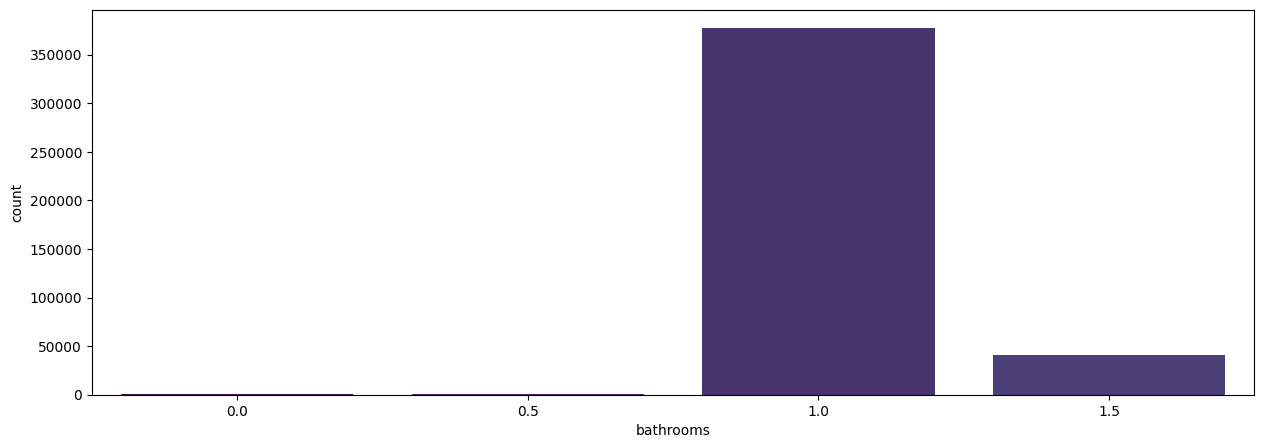

In [70]:
diagrama_caixa(base_airbnb['bathrooms'])
grafico_barra(base_airbnb['bathrooms'])

In [71]:
base_airbnb, linhas_removidas = excluir_outliners(base_airbnb, 'bathrooms')
print(f'{linhas_removidas} linhas foram removidas.')

6894 linhas foram removidas.


### 📊 Número de quartos (bedrooms)

A variável *bedrooms* indica a quantidade de quartos no imóvel.

**Principais insights:**
- A maioria dos imóveis possui 1 quarto
- Imóveis com múltiplos quartos são minoria
- Pode influenciar diretamente o conforto e o preço

**Conclusão:**
É uma variável importante para o modelo, pois reflete o tamanho e a estrutura do imóvel.

C:\Users\guilh\AppData\Local\Temp\ipykernel_3356\1083544406.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=coluna.value_counts().index, y=coluna.value_counts(), palette='viridis')


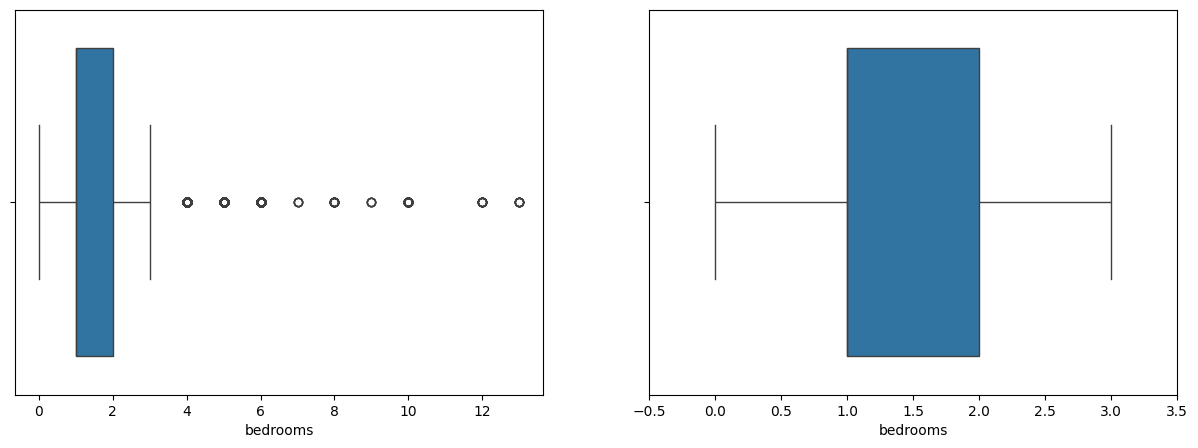

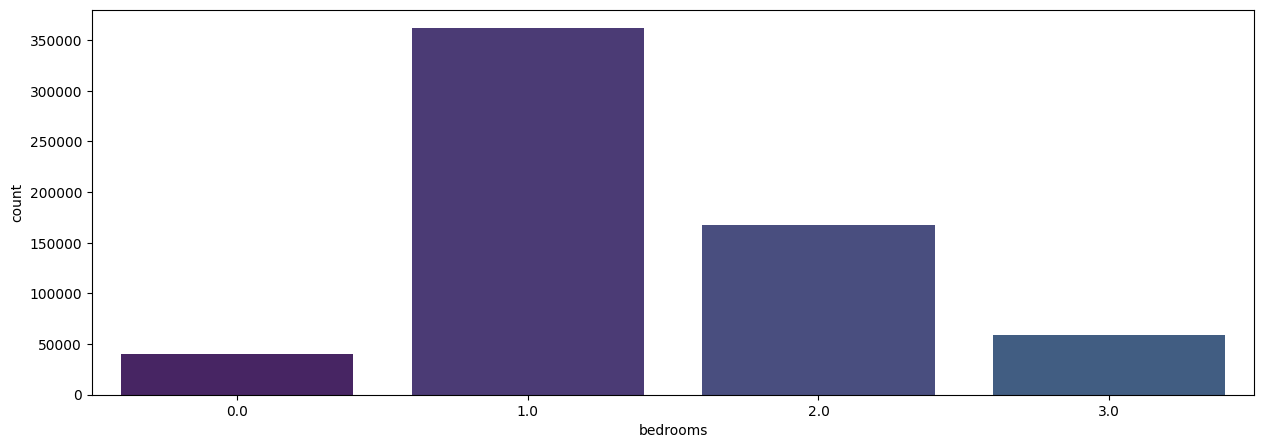

In [72]:
diagrama_caixa(base_airbnb['bedrooms'])
grafico_barra(base_airbnb['bedrooms'])

In [73]:
base_airbnb, linhas_removidas = excluir_outliners(base_airbnb, 'bathrooms')
print(f'{linhas_removidas} linhas removidas.')

0 linhas removidas.


### 📊 Número de camas (beds)

A variável *beds* representa o número de camas disponíveis no imóvel.

**Principais insights:**
- A maioria dos imóveis possui entre 1 e 2 camas
- Imóveis com muitas camas são menos comuns
- Possui possível correlação com *accommodates* e *bedrooms*

**Conclusão:**
Pode ter impacto no modelo, mas possivelmente é redundante com outras variáveis relacionadas à capacidade.

C:\Users\guilh\AppData\Local\Temp\ipykernel_3356\1083544406.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=coluna.value_counts().index, y=coluna.value_counts(), palette='viridis')


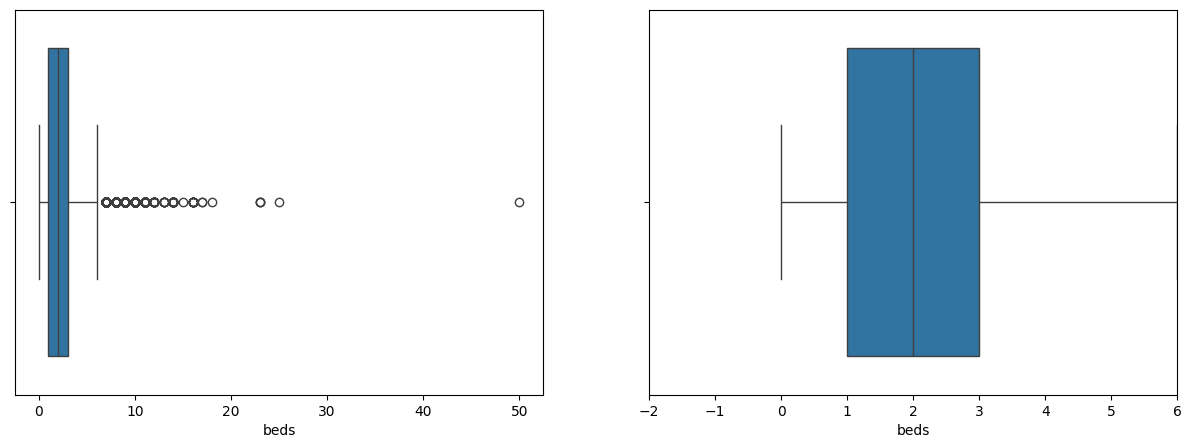

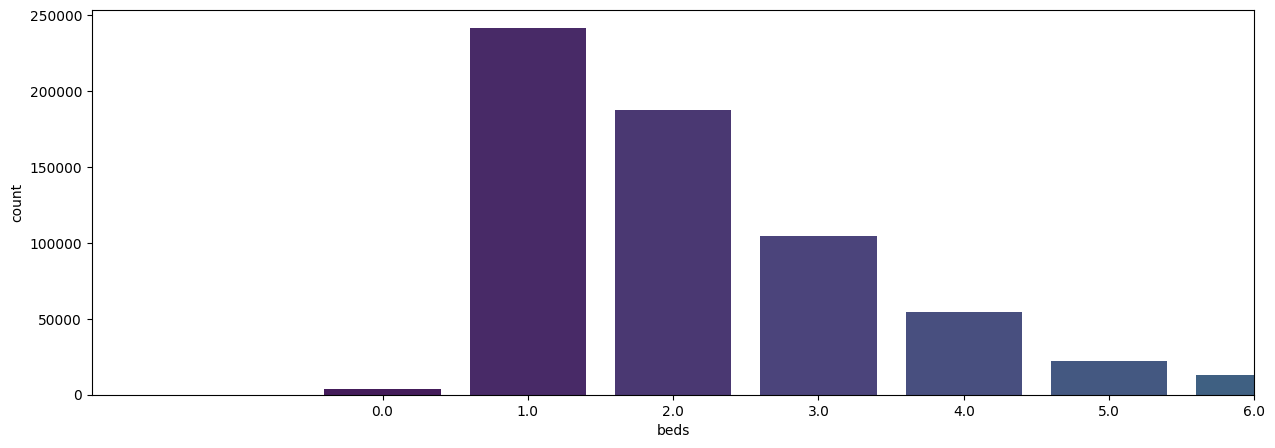

In [74]:
diagrama_caixa(base_airbnb['beds'])
grafico_barra(base_airbnb['beds'])

In [75]:
base_airbnb, linhas_removidas = excluir_outliners(base_airbnb, 'beds')
print(f'{linhas_removidas} linhas removidas.')

6460 linhas removidas.


### 📊 convidado incluso (guests_included)

**Principais insights:**
- a maioria dos imoveis tem de 1 a 2 convidados incluidos

**Conclusão:**
- vamos remover essa feature da analise. parece que os usuarios usam muito o valor padrão 1 como guests included e isso pode afetar nosso modelo de previsão.

C:\Users\guilh\AppData\Local\Temp\ipykernel_3356\1083544406.py:12: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax2.set_xlim(limites(coluna))
C:\Users\guilh\AppData\Local\Temp\ipykernel_3356\1083544406.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=coluna.value_counts().index, y=coluna.value_counts(), palette='viridis')
C:\Users\guilh\AppData\Local\Temp\ipykernel_3356\1083544406.py:25: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(limites(coluna))


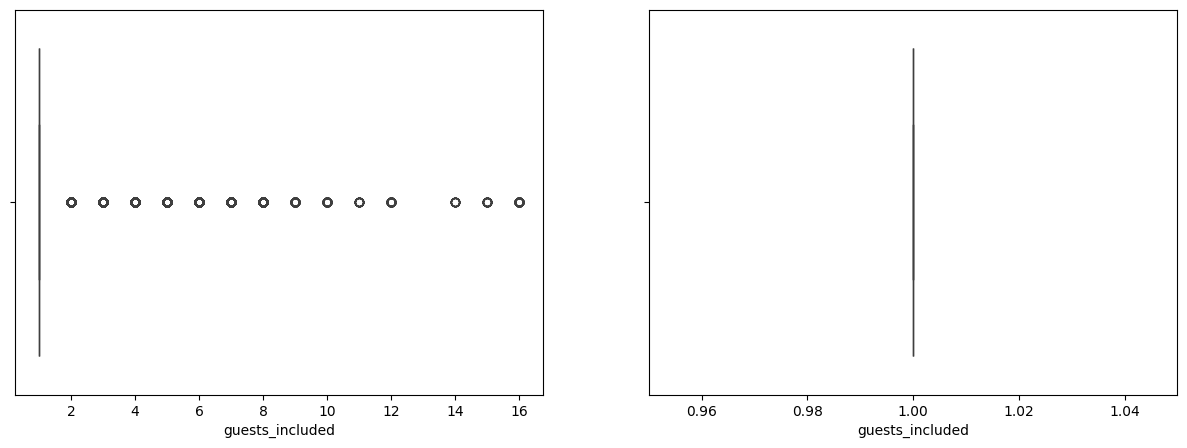

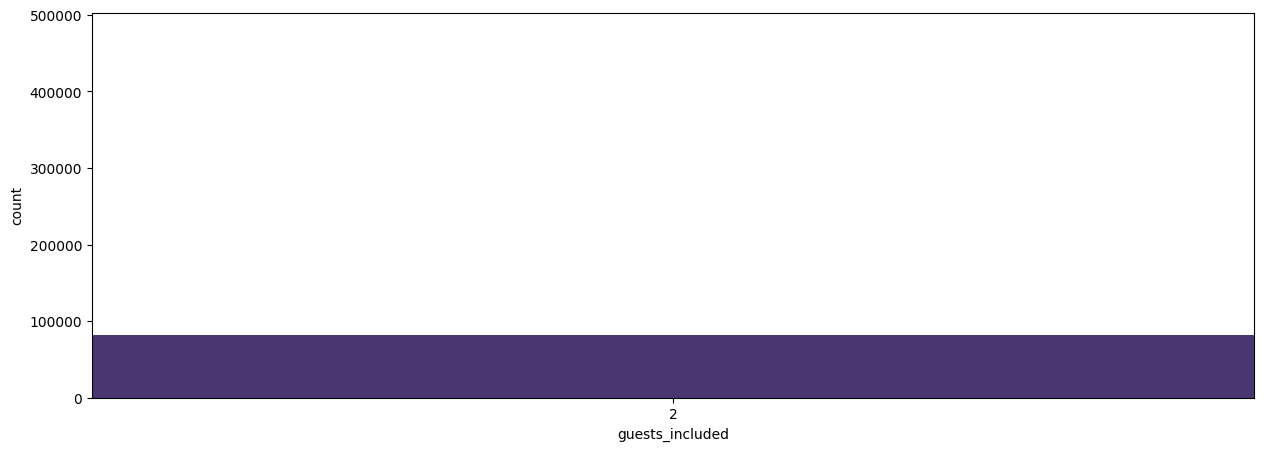

In [76]:
diagrama_caixa(base_airbnb['guests_included'])
grafico_barra(base_airbnb['guests_included'])

In [77]:
base_airbnb = base_airbnb.drop(['guests_included'], axis=1)
base_airbnb.shape

(627010, 22)

### 📊 Noites mínimas (minimum_nights)

A variável *minimum_nights* indica o número mínimo de noites exigidas na reserva.

**Principais insights:**
- A maioria dos imóveis possui baixa exigência de noites mínimas
- Alguns casos apresentam valores elevados

**Conclusão:**
Pode impactar a atratividade do imóvel, mas tem influência indireta no preço.

C:\Users\guilh\AppData\Local\Temp\ipykernel_3356\1083544406.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=coluna.value_counts().index, y=coluna.value_counts(), palette='viridis')


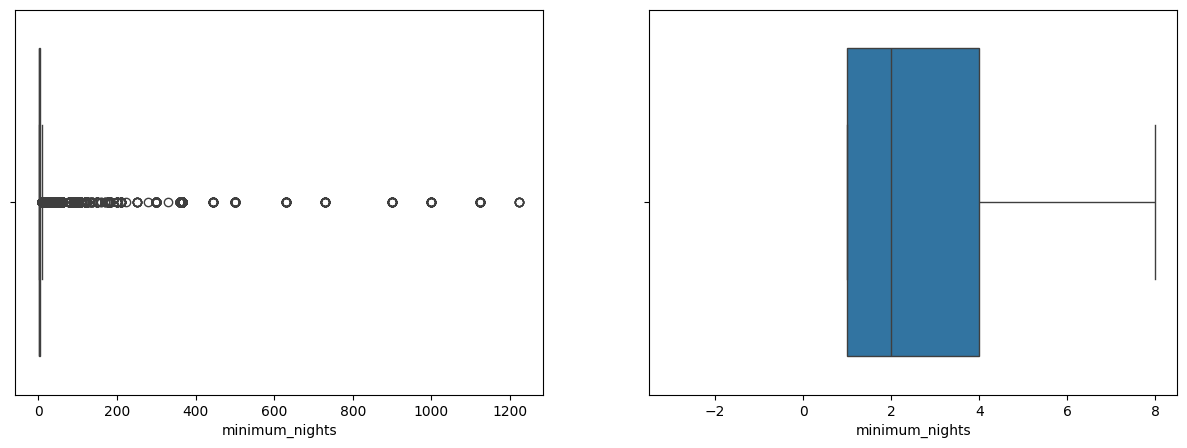

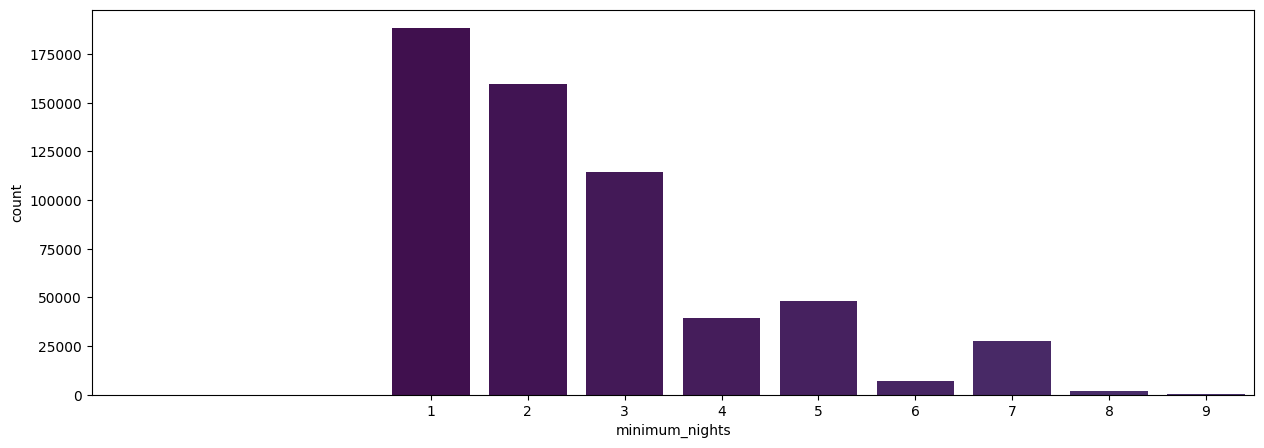

In [78]:
diagrama_caixa(base_airbnb['minimum_nights'])
grafico_barra(base_airbnb['minimum_nights'])

In [79]:
base_airbnb, linhas_removidas = excluir_outliners(
    base_airbnb, 'minimum_nights')
print(f'{linhas_removidas} linhas removidas.')

40936 linhas removidas.


### Remoção da variável maximum_nights

A variável *maximum_nights* foi removida por apresentar baixa relevância para o problema ou pouca variação nos dados, não contribuindo significativamente para a análise ou para o modelo preditivo.

In [80]:
base_airbnb = base_airbnb.drop(['maximum_nights'], axis=1)

### 📊 Número de avaliações (number_of_reviews)

A variável *number_of_reviews* representa a quantidade de avaliações recebidas.

**Principais insights:**
- Muitos imóveis possuem poucas avaliações
- Alguns possuem grande volume de reviews

**Conclusão:**
Pode indicar popularidade, mas não necessariamente influencia diretamente o preço.

C:\Users\guilh\AppData\Local\Temp\ipykernel_3356\1083544406.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=coluna.value_counts().index, y=coluna.value_counts(), palette='viridis')


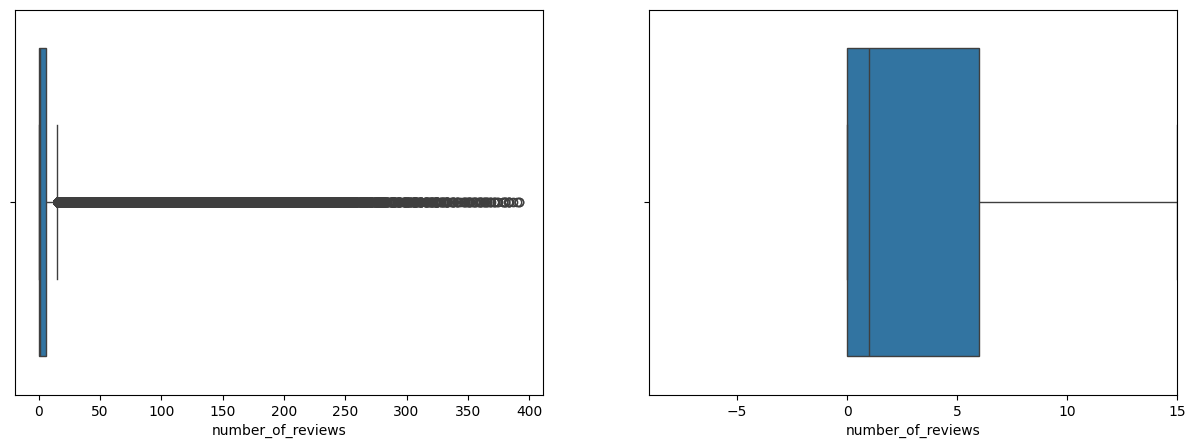

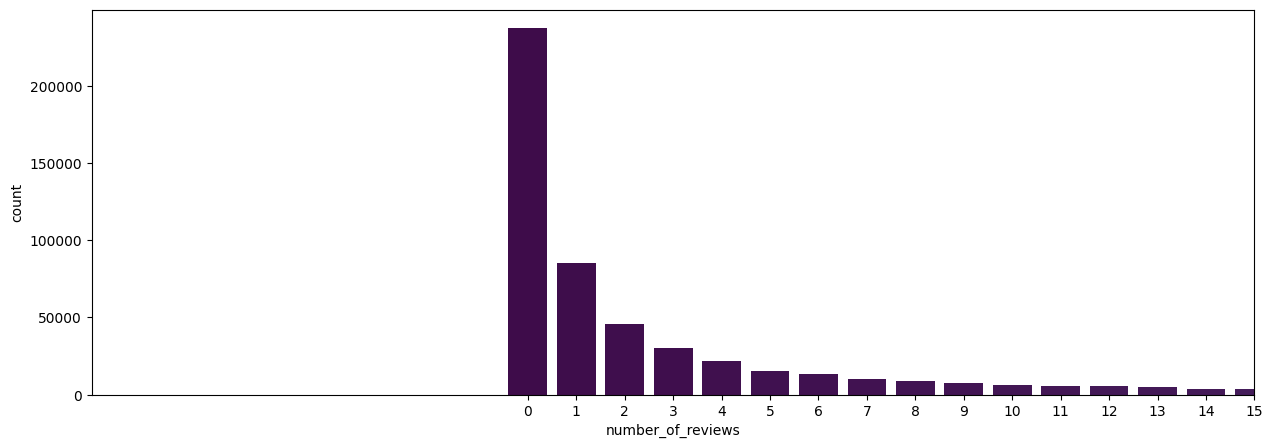

In [81]:
diagrama_caixa(base_airbnb['number_of_reviews'])
grafico_barra(base_airbnb['number_of_reviews'])

### 🧹 Tratamento de colunas com valores de texto

Nesta etapa, foram tratadas as variáveis categóricas (colunas com valores de texto), que não podem ser utilizadas diretamente em modelos de machine learning.

Para isso, foi aplicada a técnica de transformação dessas variáveis em formato numérico, permitindo que o modelo consiga interpretá-las corretamente.

Esse processo é fundamental para garantir que todas as informações relevantes sejam aproveitadas na modelagem.

property_type
Apartment                 461199
House                      52119
Condominium                26756
Serviced apartment         12674
Loft                       12359
Guest suite                 3644
Bed and breakfast           3519
Hostel                      2665
Guesthouse                  2155
Other                       1975
Villa                       1323
Townhouse                    969
Aparthotel                   709
Chalet                       482
Boutique hotel               472
Earth house                  468
Tiny house                   457
Hotel                        379
Casa particular (Cuba)       298
Cottage                      252
Bungalow                     215
Dorm                         185
Cabin                        143
Nature lodge                 124
Castle                        80
Treehouse                     76
Island                        64
Boat                          53
Hut                           40
Campsite                     

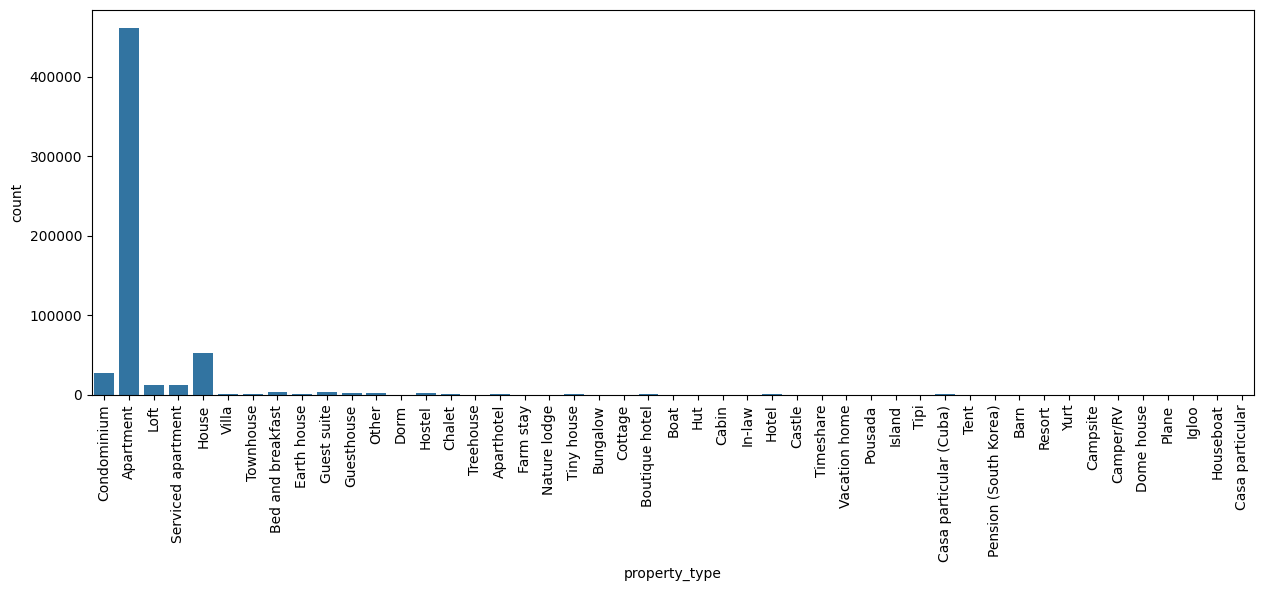

In [82]:
print(base_airbnb['property_type'].value_counts())

plt.figure(figsize=(15, 5))
grafico = sns.countplot(x='property_type', data=base_airbnb)
grafico.tick_params(axis='x', rotation=90)


property_type
Apartment                 461199
House                      52119
Condominium                26756
Serviced apartment         12674
Loft                       12359
Guest suite                 3644
Bed and breakfast           3519
Hostel                      2665
Guesthouse                  2155
Other                       1975
Villa                       1323
Townhouse                    969
Aparthotel                   709
Chalet                       482
Boutique hotel               472
Earth house                  468
Tiny house                   457
Hotel                        379
Casa particular (Cuba)       298
Cottage                      252
Bungalow                     215
Dorm                         185
Cabin                        143
Nature lodge                 124
Castle                        80
Treehouse                     76
Island                        64
Boat                          53
Hut                           40
Campsite                     

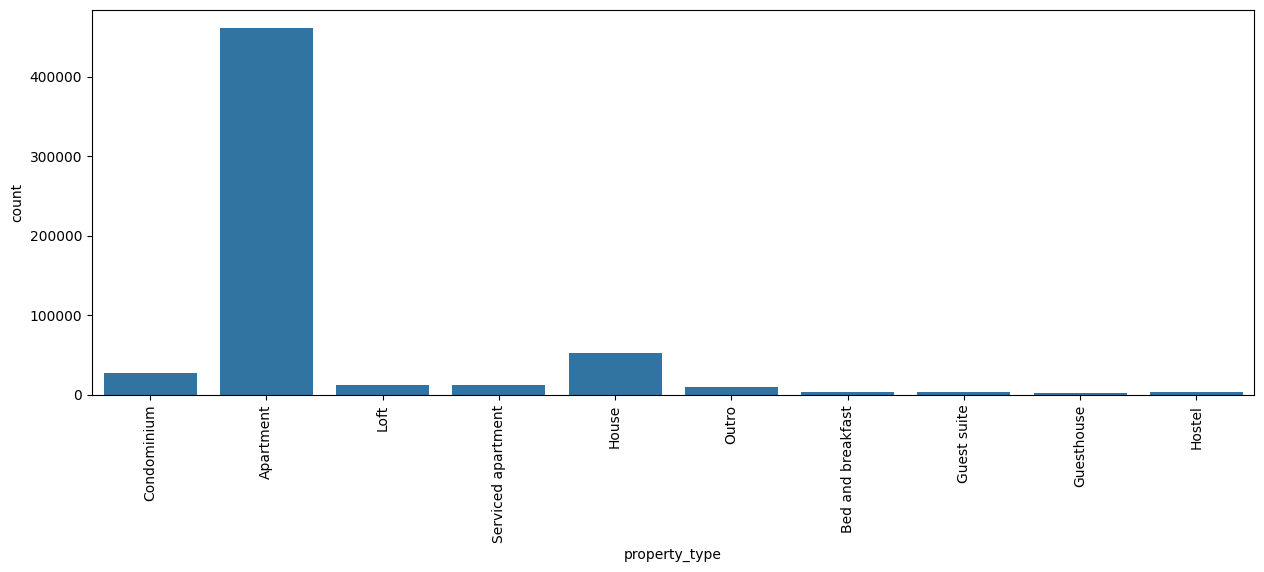

In [83]:
print(base_airbnb['property_type'].value_counts())

contagem = base_airbnb['property_type'].value_counts()

# agrupando categorias com menos de 21000 ocorrências em 'Outro'
base_airbnb['property_type'] = base_airbnb['property_type'].where(
    base_airbnb['property_type'].map(contagem) > 2100, 'Outro')
    

plt.figure(figsize=(15, 5))
grafico = sns.countplot(x='property_type', data=base_airbnb)
grafico.tick_params(axis='x', rotation=90)

### room_type

room_type
Entire home/apt    376073
Private room       197320
Shared room         11714
Hotel room            967
Name: count, dtype: int64


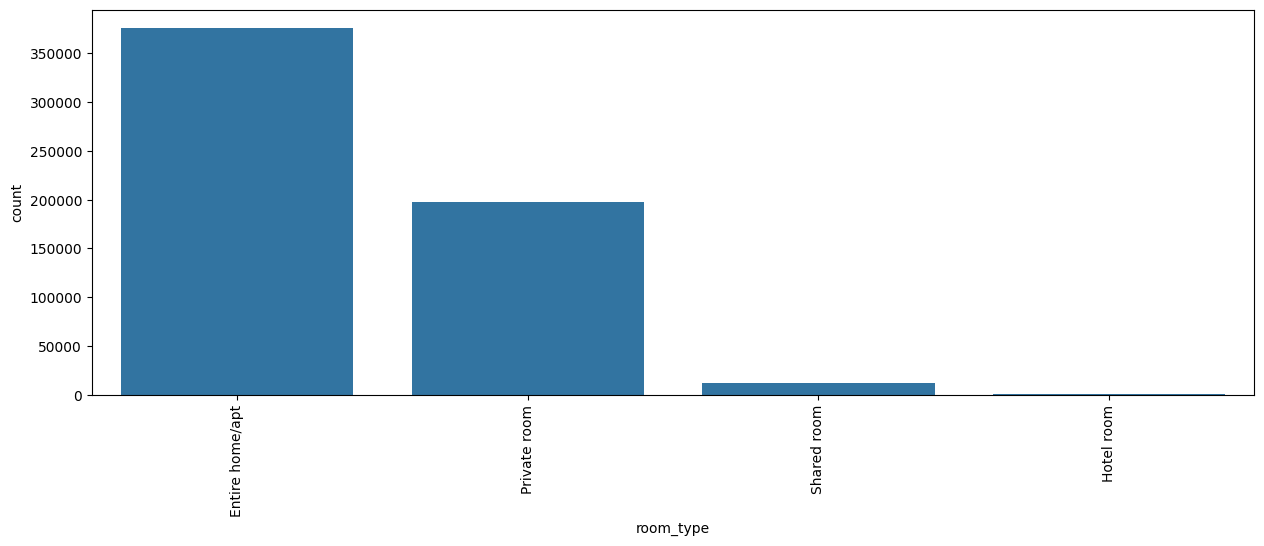

In [84]:
print(base_airbnb['room_type'].value_counts())


plt.figure(figsize=(15, 5))
grafico = sns.countplot(x='room_type', data=base_airbnb)
grafico.tick_params(axis='x', rotation=90)

### bed_type

bed_type
Real Bed         574734
Pull-out Sofa      8055
Futon              1634
Airbed             1155
Couch               496
Name: count, dtype: int64


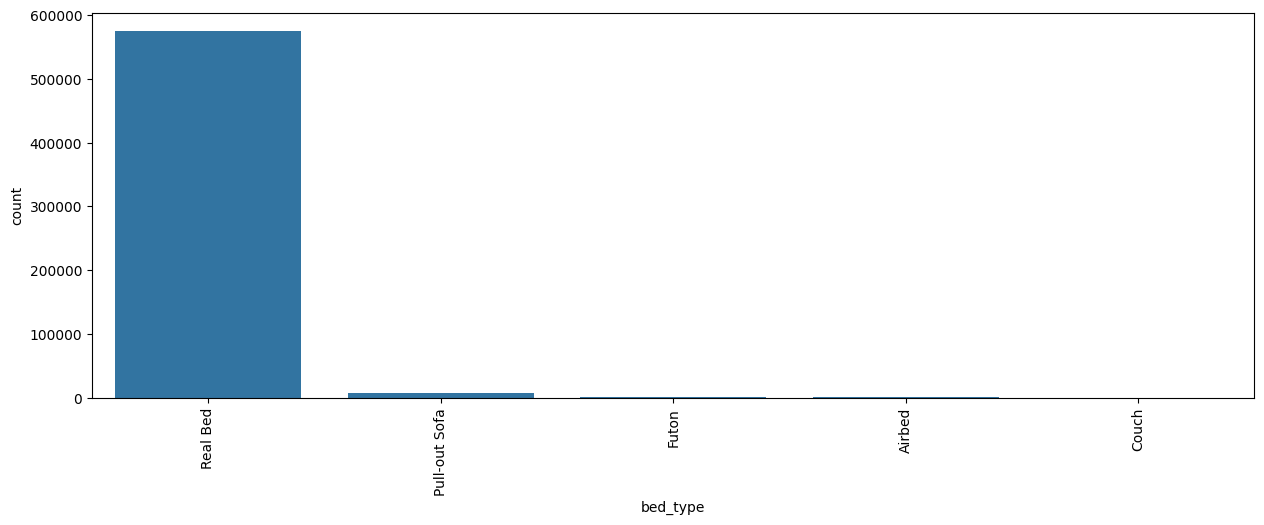

In [85]:
print(base_airbnb['bed_type'].value_counts())


plt.figure(figsize=(15, 5))
grafico = sns.countplot(x='bed_type', data=base_airbnb)
grafico.tick_params(axis='x', rotation=90)

### cancellation_policy

cancellation_policy
flexible                       259931
strict_14_with_grace_period    202362
moderate                       113837
strict                           9944
Name: count, dtype: int64


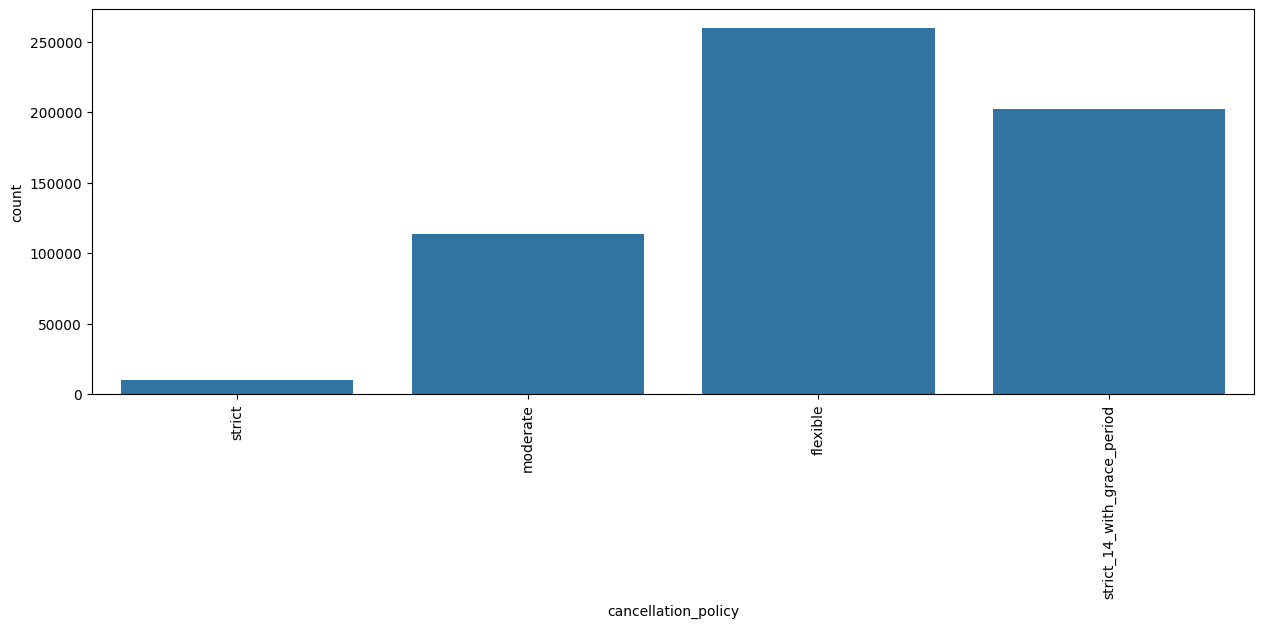

In [86]:
contagem = base_airbnb['cancellation_policy'].value_counts()

# agrupando categorias com menos de 15000 ocorrências em 'strict'
base_airbnb['cancellation_policy'] = base_airbnb['cancellation_policy'].where(
    base_airbnb['cancellation_policy'].map(contagem) > 15000 , 'strict')

print(base_airbnb['cancellation_policy'].value_counts())


plt.figure(figsize=(15, 5))
grafico = sns.countplot(x='cancellation_policy', data=base_airbnb)
grafico.tick_params(axis='x', rotation=90)

# amenities

- como temos uma diversidades muito grande de amenities e, as vezes as mesmas coisas são escrit de maneiras diferentes, vamos avaliar a quantidade de amenities como parametro.

In [87]:
print(base_airbnb['amenities'].iloc[0].split(','))
print(len(base_airbnb['amenities'].iloc[0].split(',')))


base_airbnb['num_amenities'] = base_airbnb['amenities'].apply(lambda x: len(x.split(',')))
base_airbnb = base_airbnb.drop(['amenities'], axis=1)
base_airbnb.shape


['{TV', '"Cable TV"', 'Internet', 'Wifi', '"Air conditioning"', 'Kitchen', '"Paid parking off premises"', '"Smoking allowed"', 'Doorman', 'Elevator', '"Hot tub"', '"Family/kid friendly"', '"Suitable for events"', 'Essentials', '"24-hour check-in"', 'Hangers', '"Hair dryer"', 'Iron', '"Laptop friendly workspace"', '"Self check-in"', '"Front desk/doorperson"', '"Private entrance"', '"Hot water"', '"Bed linens"', '"Luggage dropoff allowed"}']
25


(586074, 21)

C:\Users\guilh\AppData\Local\Temp\ipykernel_3356\1083544406.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=coluna.value_counts().index, y=coluna.value_counts(), palette='viridis')


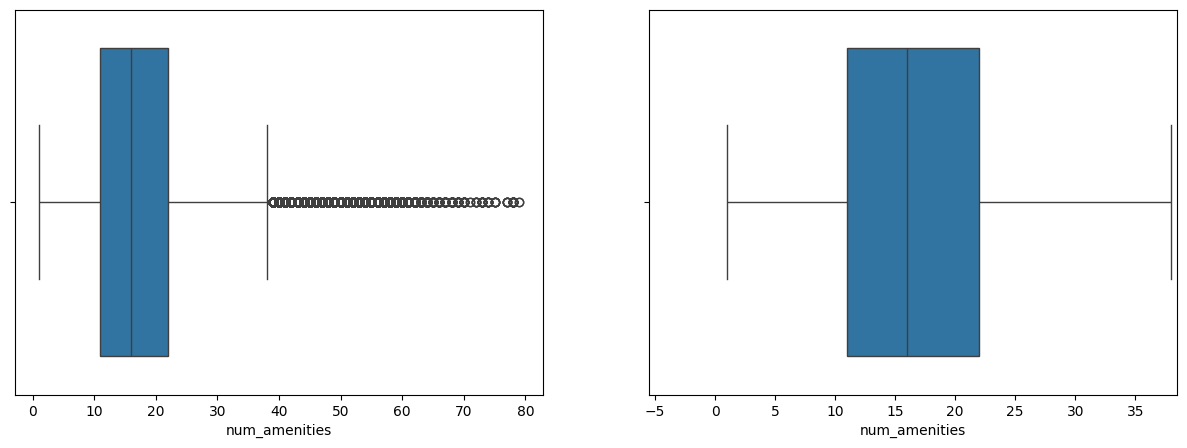

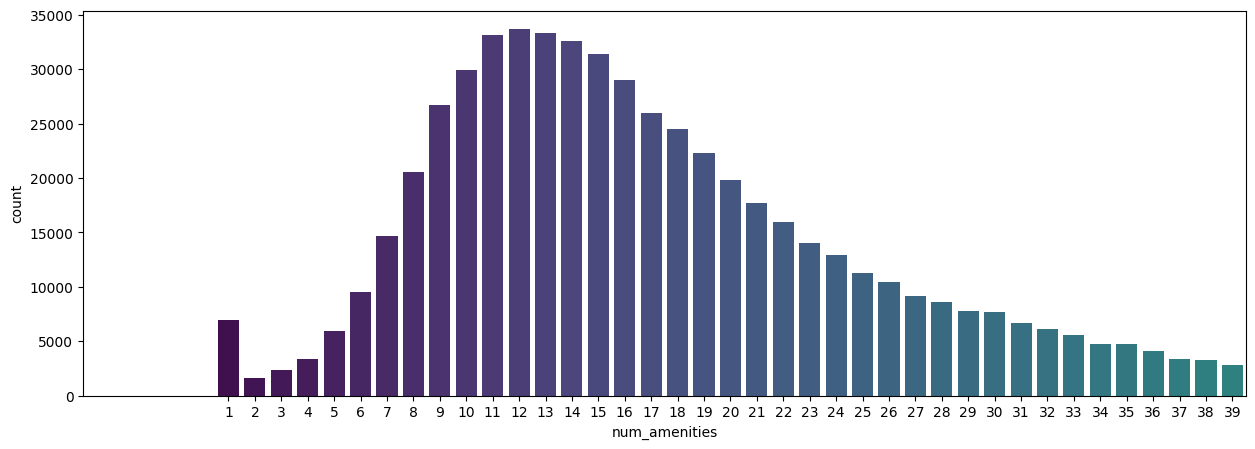

In [88]:

diagrama_caixa(base_airbnb['num_amenities'])
grafico_barra(base_airbnb['num_amenities'])

In [89]:
base_airbnb, linhas_removidas = excluir_outliners(base_airbnb, 'num_amenities')
print(linhas_removidas)

24563


### 🗺️ Visualização geográfica das propriedades

Nesta etapa, foi realizada a visualização das propriedades no mapa, utilizando suas coordenadas geográficas (latitude e longitude).

**Principais insights:**
- As propriedades estão concentradas em regiões específicas da cidade
- Áreas mais turísticas apresentam maior densidade de anúncios
- Regiões com maior concentração podem indicar maior competitividade entre anfitriões

**Conclusão:**
A localização é um fator essencial na precificação dos imóveis, influenciando diretamente a demanda e o valor das diárias. Essa análise reforça a importância de variáveis geográficas no modelo preditivo.

In [90]:
# podemos pegar uma amostra, para o grafico ficar mais facil de ler ou exibir tudo.

amostra = base_airbnb.sample(n=50000)
centro_mapa = {'lat': amostra.latitude.mean(), 'lon': amostra.longitude.mean()}
mapa = px.density_map(amostra,
                         lat='latitude',
                         lon='longitude',
                         z='price',
                         radius=2.5,
                         center=centro_mapa,
                         zoom=10,
                      map_style='open-street-map')

mapa.show()

### Encoding

precisamos ajustar as features para facilitar o trabalho do modelo futuro (features de categoria, True e False, etc).

- features com valores True ou False, vamos subistituir True por 1 e False por 0.
- features de categoria (features em que os valores da coluna são em texto) vamos ultilizar o método enconding de variáveis dummies.

In [91]:
colunas_tf = ['host_is_superhost', 'instant_bookable', 'is_business_travel_ready']

base_airbnb_cod = base_airbnb.copy()
for coluna in colunas_tf:
    base_airbnb_cod[coluna] = base_airbnb_cod[coluna].map({'t': 1, 'f': 0})


In [92]:
colunas_categorias = ['property_type', 'room_type', 'bed_type', 'cancellation_policy']

base_airbnb_cod = pd.get_dummies(data=base_airbnb_cod, columns=colunas_categorias)

display(base_airbnb_cod.head())

,host_is_superhost,host_total_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,beds,price,extra_people,...,room_type_Shared room,bed_type_Airbed,bed_type_Couch,bed_type_Futon,bed_type_Pull-out Sofa,bed_type_Real Bed,cancellation_policy_flexible,cancellation_policy_moderate,cancellation_policy_strict,cancellation_policy_strict_14_with_grace_period
1,1,2.0,-22.965919,-43.178962,5,1.0,2.0,2.0,270.0,51.0,...,False,False,False,False,False,True,False,False,True,False
3,0,3.0,-22.977117,-43.190454,3,1.0,1.0,2.0,161.0,45.0,...,False,False,False,False,False,True,False,False,True,False
4,1,1.0,-22.983024,-43.214270,3,1.0,1.0,2.0,222.0,68.0,...,False,False,False,False,False,True,False,False,True,False
5,1,1.0,-22.988165,-43.193588,3,1.5,1.0,2.0,308.0,86.0,...,False,False,False,False,False,True,False,False,True,False
6,1,1.0,-22.981269,-43.190457,2,1.0,1.0,2.0,219.0,80.0,...,False,False,False,False,False,True,False,False,True,False


## 📈 Avaliação do Modelo

O modelo foi avaliado utilizando métricas de regressão, como:

- Erro Médio Absoluto (MAE)
- Erro Quadrático Médio (RMSE)

Os resultados indicam que o modelo é capaz de capturar padrões relevantes dos dados e fornecer boas estimativas de preço.

In [93]:
def avaliar_modelo(modelo, y_teste, previsao):
    r2 = r2_score(y_teste, previsao)
    RSME = np.sqrt(mean_squared_error(y_teste, previsao))
    return f'modelo {modelo}: \nR²: {r2:.2%}\nRSME: {RSME:.4f}'

- escolha do modelo a serem testados

1. RandomForest
2. LinearRegression
3. Extra Tree


In [94]:
modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
modelo_lr = LinearRegression()
modelo_et = ExtraTreesRegressor(n_estimators=100, random_state=42, max_depth=10)

modelos = {'RandomForest': modelo_rf,
           'LinearRegression': modelo_lr,
           'ExtraTrees': modelo_et, }


y = base_airbnb_cod['price']
x = base_airbnb_cod.drop(['price'], axis=1)

## 🤖 Escolha do Modelo

Foi utilizado o algoritmo Extra Trees Regressor por sua capacidade de capturar relações não lineares e lidar bem com dados tabulares.

esse foi o modelo com maior valor de R² e ao mesmo tempo o menor valor de RSME. Como não tivemos uma grande diferença de velocidade de treino e de previsão.

o modelo de LinearRegression não obteve um resultado satifatorio, com valores de R² e RSME muito piores que outros modelos.

    modelo escolhido como melhor modelo: RandomForest

⚙️ Otimização do Modelo para Deploy

Durante o desenvolvimento do projeto, foram testadas versões mais complexas do modelo que apresentaram melhor desempenho preditivo. No entanto, essas versões geravam arquivos muito grandes (na ordem de gigabytes), o que inviabiliza sua utilização em ambientes reais de aplicação.

Plataformas de deploy, como o Streamlit Cloud, possuem limitações de armazenamento, memória e tempo de execução. Modelos muito pesados dificultam o carregamento da aplicação, aumentam o tempo de resposta e podem até impedir a execução do sistema.

Por esse motivo, foi adotada uma versão otimizada do modelo, com redução de complexidade (como limitação de profundidade e número de estimadores), mantendo um bom equilíbrio entre desempenho e eficiência computacional.

Essa decisão reflete uma prática comum no mercado, onde o objetivo não é apenas maximizar a precisão do modelo, mas garantir que ele seja utilizável, escalável e eficiente em ambiente de produção.

Em resumo, o modelo final foi escolhido considerando:

Desempenho preditivo satisfatório
Baixo custo computacional
Facilidade de deploy e uso em aplicações reais

In [95]:
X_train, X_test, y_train, y_test = train_test_split(x, y, random_state=42)

for nome_modelo, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    previsao = modelo.predict(X_test)
    print(avaliar_modelo(nome_modelo, y_test, previsao))
    

modelo RandomForest: 
R²: 53.65%
RSME: 181.6640
modelo LinearRegression: 
R²: 33.61%
RSME: 217.4230
modelo ExtraTrees: 
R²: 47.21%
RSME: 193.8790


### Ajustes e Melhorias no Melhor Modelo

,0
room_type_Entire home/apt,0.204780
extra_people,0.181959
bathrooms,0.153988
bedrooms,0.121424
accommodates,0.101152
number_of_reviews,0.062558
minimum_nights,0.045281
host_is_superhost,0.025726
cancellation_policy_flexible,0.018865
latitude,0.015000


C:\Users\guilh\AppData\Local\Temp\ipykernel_3356\3754703050.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=importancia_features.index, y=importancia_features[0], palette='viridis')


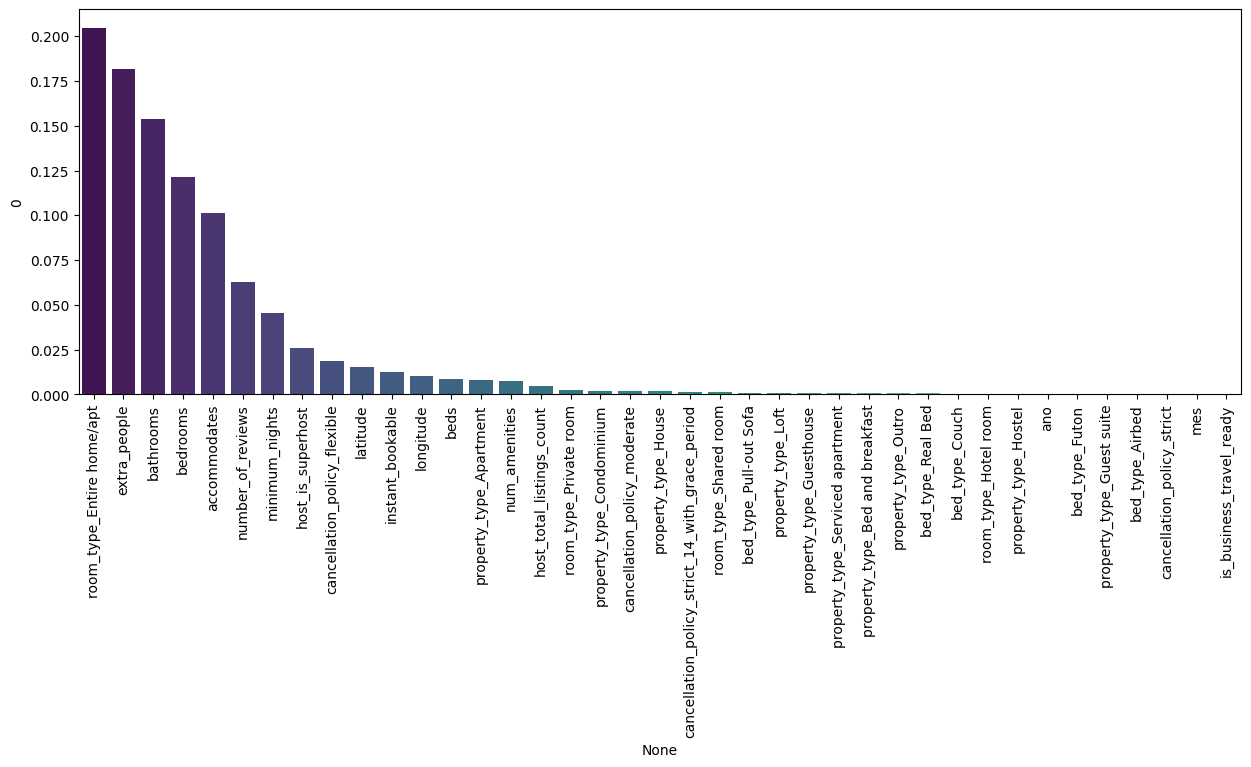

In [96]:
importancia_features = pd.DataFrame(modelo_et.feature_importances_, X_train.columns)
importancia_features = importancia_features.sort_values(by=0, ascending=False)
display(importancia_features)
plt.figure(figsize=(15, 5))
ax = sns.barplot(x=importancia_features.index, y=importancia_features[0], palette='viridis')
ax.tick_params(axis='x', rotation=90)


### ajustes finais do modelo
algumas colunas parecer nao ter tanto impacto no nosso modelo, por isso para obter um modelo mais simples e rapido iremos excluir essa coluna

In [97]:
base_teste = base_airbnb_cod.copy()
base_teste = base_teste.drop(['is_business_travel_ready'], axis=1)

y = base_teste['price']
x = base_teste.drop(['price'], axis=1)

X_train, X_test, y_train, y_test = train_test_split(x, y, random_state=42)

modelo_rf.fit(X_train, y_train)
previsao = modelo_rf.predict(X_test)
print(avaliar_modelo('RandomForest', y_test, previsao))

modelo RandomForest: 
R²: 53.65%
RSME: 181.6658


In [98]:
base_teste = base_teste.drop(columns=base_teste.filter(like='bed_type').columns)

print(base_teste.columns)
y = base_teste['price']
x = base_teste.drop(['price'], axis=1)

X_train, X_test, y_train, y_test = train_test_split(x, y, random_state=42)


modelo_rf.fit(X_train, y_train)
previsao = modelo_rf.predict(X_test)
print(avaliar_modelo('RandomForest', y_test, previsao))

Index(['host_is_superhost', 'host_total_listings_count', 'latitude',
       'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'price',
       'extra_people', 'minimum_nights', 'number_of_reviews',
       'instant_bookable', 'ano', 'mes', 'num_amenities',
       'property_type_Apartment', 'property_type_Bed and breakfast',
       'property_type_Condominium', 'property_type_Guest suite',
       'property_type_Guesthouse', 'property_type_Hostel',
       'property_type_House', 'property_type_Loft', 'property_type_Outro',
       'property_type_Serviced apartment', 'room_type_Entire home/apt',
       'room_type_Hotel room', 'room_type_Private room',
       'room_type_Shared room', 'cancellation_policy_flexible',
       'cancellation_policy_moderate', 'cancellation_policy_strict',
       'cancellation_policy_strict_14_with_grace_period'],
      dtype='str')
modelo RandomForest: 
R²: 53.61%
RSME: 181.7540


In [101]:
x['price'] = y
x.head(1000).to_csv('dados_tratado/dados.csv', sep=';')

In [100]:
import joblib
joblib.dump(modelo_rf, 'modelo/modelo_rf.joblib')

['modelo/modelo_rf.joblib']

## 🧾 Conclusão

Ao longo deste projeto, foi possível analisar e compreender os principais fatores que influenciam o preço de imóveis anunciados no Airbnb no Rio de Janeiro.

A análise exploratória evidenciou que variáveis como capacidade de hóspedes (*accommodates*), tipo de acomodação (*room_type*) e localização exercem forte influência sobre a precificação dos imóveis. Por outro lado, algumas variáveis apresentaram menor impacto ou redundância, contribuindo de forma limitada para o modelo.

Com base nesses dados, foi desenvolvido um modelo de machine learning capaz de prever o preço das diárias, demonstrando que é possível capturar padrões relevantes a partir das características dos imóveis. A avaliação do modelo indicou um desempenho consistente, embora ainda existam oportunidades de melhoria.

Como próximos passos, recomenda-se a otimização dos hiperparâmetros, a criação de novas variáveis (feature engineering) e a exploração de modelos mais avançados, visando aumentar a precisão das previsões.

De forma geral, o projeto reforça o potencial da análise de dados como ferramenta estratégica para apoiar decisões no setor de hospedagem e precificação de imóveis.



## 🚀 Próximos Passos

- Deploy da aplicação com Streamlit
- Criação de API com Django
- Integração com dashboard
- Otimização do modelo